In [19]:
# Assignment 1 – Ryann Tompkins
import pandas as pd

df = pd.read_csv(
    r"C:\Users\ryann\Downloads\bank-additional.csv",
    sep=";"
)
print(df.head())


   age          job  marital          education default  housing     loan  \
0   30  blue-collar  married           basic.9y      no      yes       no   
1   39     services   single        high.school      no       no       no   
2   25     services  married        high.school      no      yes       no   
3   38     services  married           basic.9y      no  unknown  unknown   
4   47       admin.  married  university.degree      no      yes       no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0   cellular   may         fri  ...         2    999         0  nonexistent   
1  telephone   may         fri  ...         4    999         0  nonexistent   
2  telephone   jun         wed  ...         1    999         0  nonexistent   
3  telephone   jun         fri  ...         3    999         0  nonexistent   
4   cellular   nov         mon  ...         1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.e

In [8]:
# 1. Addressing Class Imbalance
## 1.1 Class Distribution

df["y"].value_counts(normalize=True) * 100

### The training set displays strong class imbalance: about 89% of clients did not subscribe , while only about 11% did. This imbalance is substantial and may bias a classifier toward predicting the majority class. A classifier predicting only “no” would already achieve high accuracy (~89%), making accuracy alone an unreliable evaluation metric.

## 1.2 Reassembling Strategy

from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:\n", y_train.value_counts(normalize=True))
print("\nAfter SMOTE:\n", y_train_resampled.value_counts(normalize=True))
## 1.3 Justification

## 1.4 Implications of Model Evaluation

## 1.5 Affect of evaluation metrics

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

Shape of dataset: (4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx  

C:\Users\ryann\AppData\Local\Temp\ipykernel_33952\724263018.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")
C:\Users\ryann\AppData\Local\Temp\ipykernel_33952\724263018.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#s

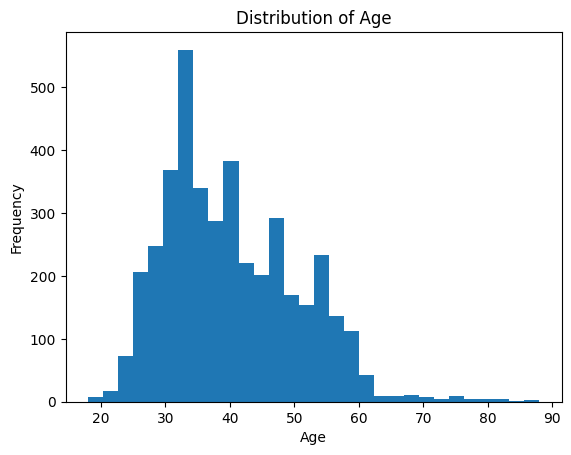

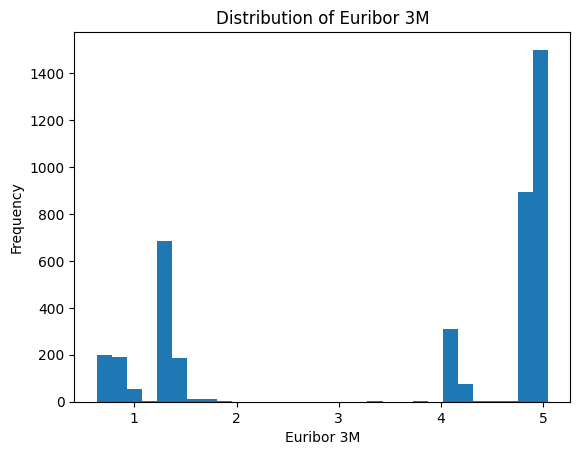

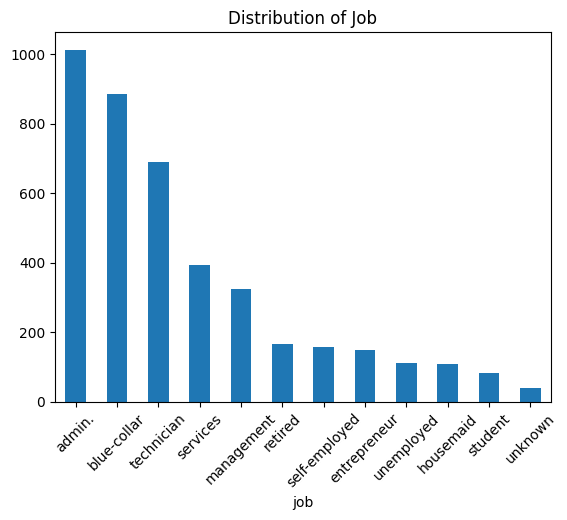

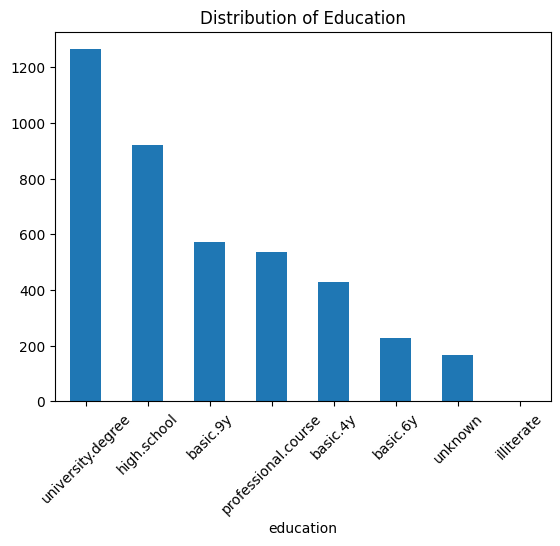

count    4119.000000
mean      256.788055
std       254.703736
min         0.000000
25%       103.000000
50%       181.000000
75%       317.000000
max      3643.000000
Name: duration, dtype: float64

In [15]:
# 2. Data Loading & Exploration
## 2.1 Inspecting dataframe
print("Shape of dataset:", df.shape)
df.info()
df.describe()
df.describe(include="object")

## 2.2 Identifying Categorical v Numerical
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

## 2.3 Analyze Distribution
df["y"].value_counts()
df["y"].value_counts(normalize=True)

### The target variable exhibits clear class imbalance. The majority class (“no”) represents approximately 89% of the observations, while the minority class (“yes”) represents approximately 11%.

## 2.4 Explicit and Implicit Missing
df.isnull().sum()

### While the explicit missing values come up as 0, that does not mean there are not implicit missing values.

(df == "unknown").sum()

### Here, we can see that that many categories have "unknown" rather than missing values, showing the presence of implicit missing values.
## 2.5 Visualization

import matplotlib.pyplot as plt
plt.hist(df["age"], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["euribor3m"], bins=30)
plt.title("Distribution of Euribor 3M")
plt.xlabel("Euribor 3M")
plt.ylabel("Frequency")
plt.show()

df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job")
plt.xticks(rotation=45)
plt.show()

df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education")
plt.xticks(rotation=45)
plt.show()

## 2.6 Special Consideration

df["duration"].describe()

In [17]:
# 3. Data Splitting
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 3.1 Split data into sets
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


## 3.2 Justification

### I decided to split 70% for the training set, 15% for validation, and 15% for test set. The training set must be large to allow reliable estimation of model parameters. The validation set is used for model selection and hyperparameter tuning, while the test set provides an unbiased estimate of generalization performance. This split balances statistical reliability with sufficient data for evaluation.

## 3.3 Stratified Split

 ### As stated earlier the dataset exhibits strong class imbalance, without stratification the minority class might be underrepresented in the validation or test sets, leading to unreliable performance estimates.Stratified splitting ensures that each subset preserves the original class proportions.

## 3.4 Stages

### The dataset must be split before any transformation that learns parameters from data. If splitting were performed later, information from validation and test sets could influence preprocessing steps, leading to data leakage.

Training size: (2883, 20)
Validation size: (618, 20)
Test size: (618, 20)


In [18]:
# 4. Encoding Categorical Variables
## 4.1 Identify Categoricals
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)
## 4.2 Nominal v Ordinal

### The only ordinal variable is education, this is because there is a hierarchal order to it (least to ost educated). This leaves job, marital, default, housing, loan, contact, month, day_of_week, y, and poutcome.

## 4.3 Encoding Strategy
education_order = {
    "basic.4y": 1,
    "basic.6y": 2,
    "basic.9y": 3,
    "high.school": 4,
    "professional.course": 5,
    "university.degree": 6,
    "illiterate": 0,
    "unknown": -1
}

X_train["education"] = X_train["education"].map(education_order)
X_val["education"] = X_val["education"].map(education_order)
X_test["education"] = X_test["education"].map(education_order)

nominal_cols = categorical_cols.drop("education")

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
## 4.4 Encoder Fitting

### Encoding decisions must be made using training sets only. If they were decided using the entire dataset it could lead to data leakage.

## 4.5 Analysis

### One-hot encoding increases dimensionality, allowing Logistic Regression model to display category specific shifts. The model can now create linear decision boundaries that differ across categories.

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


C:\Users\ryann\AppData\Local\Temp\ipykernel_33952\307059220.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [ ]:
# 5. Feature Scaling
## 5.1 Identification
print(numerical_cols)
## 5.2 Application of Strategy
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
## 5.3 Justification

### Logistic Regression uses regularization and need comparable feature scales.

## 5.4 Fitted on Training Set

### The scaler must be fitted on the training set only because it estimates parameters.If fitted on the entire dataset, information from validation and test sets would influence the scaling parameters, resulting in data leakage.

## 5.5 Affects of Feature Scaling

### Gradient-Based Optimization: Scaling ensures stable and efficient convergence.

### Coefficient Comparability: Without scaling, coefficients are not comparable.

### Regularization: Regularization penalizes large coefficients. If features are on different scales, regularization unfairly penalizes some features more than others.


In [22]:
# 6. Feature Selection
## 6.1 Low Variance Features
X_train.var().sort_values().head()
low_variance_cols = X_train.var()[X_train.var() < 0.01].index
low_variance_cols

In [20]:
X_train = X_train.drop(columns=low_variance_cols)
X_val = X_val.drop(columns=low_variance_cols)
X_test = X_test.drop(columns=low_variance_cols

### Features with extremely low variance contain little information for classification and may introduce numerical instability.

## 6.2 Correlated Numerical Features
corr_matrix = X_train.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

high_corr
## 6.3 Conceptual Considerations
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])
## 6.4 Why?

### The variable duration must be removed because it is only known after the call is completed, introducing data leakage.

## 6.5 Consequences before splitting

### Feature selection based on the entire dataset would allow validation and test data to influence which features are retained, leading to optimistic bias and compromised evaluation.

_IncompleteInputError: incomplete input (4123655769.py, line 18)

In [23]:
# 7. Identify Prediction Target
## 7.1 Target Variable
df.columns
target = "y"
## 7.2 Justify

### The column y represents whether the client subscribed to a term deposit (“yes” or “no”). This aligns directly with the business objective of the marketing campaign: predicting whether a contacted client will subscribe. Therefore, y is the appropriate prediction target.

## 7.3 2 Other Options

### Although duration appears strongly predictive, it is only known after the phone call is completed. Using it would introduce data leakage because the prediction is meant to occur at the time of contact.Similarly, poutcome reflects outcomes from previous campaigns and does not represent the current campaign objective.

In [ ]:
# 8. Managing Missing Values
## 8.1 Explicit and Implicit Missing Values
df.isnull().sum()
(df == "unknown").sum()

### Several categorical variables contain the category “unknown,” which represents implicit missingness.

## 8.2 Handling Missing Values
X_train["pdays_never_contacted"] = (X_train["pdays"] == 999).astype(int)
X_val["pdays_never_contacted"] = (X_val["pdays"] == 999).astype(int)
X_test["pdays_never_contacted"] = (X_test["pdays"] == 999).astype(int)

## 8.3 Fitted Operations

### Imputation parameters must be computed using the training set only to avoid incorporating information from validation or test data.

In [ ]:
## 9. Task Ordering


In [ ]:
# 10. Training a Logistic Regression Model
## 10.1 Training
y_train_binary = (y_train == "yes").astype(int)
y_val_binary = (y_val == "yes").astype(int)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train_binary)
y_val_pred = model.predict(X_val)
## 10.2 Validation Set
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_val_binary, y_val_pred)
precision = precision_score(y_val_binary, y_val_pred)
recall = recall_score(y_val_binary, y_val_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
## 10.3 Report

## 10.4 Zero Line
zero_rule_pred = np.zeros_like(y_val_binary)

zero_rule_accuracy = accuracy_score(y_val_binary, zero_rule_pred)

print("Zero Rule Accuracy:", zero_rule_accuracy)

In [ ]:
## 11. Final Discussion